In [1]:
import sys
print(sys.executable)

c:\Users\84969\Desktop\Projects\Technical Projects\ML\Ecommerce_Churn_Prediction_Machine_Learning_Pipeline\.venv\Scripts\python.exe


In [1]:
import shap
print(shap.__version__)

c:\Users\84969\Desktop\Projects\Technical Projects\ML\Ecommerce_Churn_Prediction_Machine_Learning_Pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.52.0


In [2]:
import matplotlib
print(matplotlib.__version__)

3.11.0


In [3]:
import os
import sys
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [4]:
sys.path.append(os.path.abspath("../preprocessing"))

from preprocess_churn import load_and_prepare_data

data = load_and_prepare_data()

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

X_train.shape, X_test.shape

((4504, 27), (1126, 27))

In [5]:
selected_model = joblib.load("../../06_models/random_forest_churn_model.pkl")

selected_model

c:\Users\84969\Desktop\Projects\Technical Projects\ML\Ecommerce_Churn_Prediction_Machine_Learning_Pipeline\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\84969\Desktop\Projects\Technical Projects\ML\Ecommerce_Churn_Prediction_Machine_Learning_Pipeline\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\84969\Desktop\Projects\T

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['tenure','city_tier','warehouse_to_home',...,'has_complaint', 'inactive_customer_flag','high_cashback_customer_flag']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [6]:
preprocessor = selected_model.named_steps["preprocessor"]
rf_model = selected_model.named_steps["model"]

preprocessor, rf_model

(ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['tenure', 'city_tier', 'warehouse_to_home',
                                   'hour_spend_on_app',
                                   'number_of_device_registered',
                                   'satisfaction_score', 'number_of_address',
                                   'complain',
                                   'order_amount_hike_from_last_year',
                                   'coupon_used', 'order_count',
                                   'day_since_last_order', 'cashback_amount',
                                   'tenure_missing_flag',
                                   'warehouse_to_home_missing_flag',
                                   'hour_spend_on_app_missing_flag',
                                   'day_since_last_order_missing_flag',
                                   'is_new_customer', 'low_satisfaction_flag',
                                   'has_complaint', 'i

In [7]:
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

X_test_transformed_df.head()

,num__tenure,num__city_tier,num__warehouse_to_home,num__hour_spend_on_app,num__number_of_device_registered,num__satisfaction_score,num__number_of_address,num__complain,num__order_amount_hike_from_last_year,num__coupon_used,num__order_count,num__day_since_last_order,num__cashback_amount,num__tenure_missing_flag,num__warehouse_to_home_missing_flag,num__hour_spend_on_app_missing_flag,num__day_since_last_order_missing_flag,num__is_new_customer,num__low_satisfaction_flag,num__has_complaint,num__inactive_customer_flag,num__high_cashback_customer_flag,cat__preferred_login_device_computer,cat__preferred_login_device_mobile phone,cat__preferred_payment_mode_cash on delivery,cat__preferred_payment_mode_credit card,cat__preferred_payment_mode_debit card,cat__preferred_payment_mode_e wallet,cat__preferred_payment_mode_upi,cat__gender_female,cat__gender_male,cat__preferred_order_cat_fashion,cat__preferred_order_cat_grocery,cat__preferred_order_cat_laptop & accessory,cat__preferred_order_cat_mobile,cat__preferred_order_cat_mobile phone,cat__preferred_order_cat_others,cat__marital_status_divorced,cat__marital_status_married,cat__marital_status_single
0,0.846326,1.453559,-0.674073,1.291048,0.294877,-1.493573,-0.466857,-0.623912,1.232837,2.296687,1.796587,1.006410,0.094099,-0.222798,-0.218928,-0.213868,-0.240878,-0.867484,1.489779,-0.623912,-0.298728,-0.564359,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.890416,1.453559,-0.224841,0.211219,0.294877,-1.493573,1.482635,1.602791,0.617330,-0.887474,-0.636105,-1.164635,0.644226,-0.222798,-0.218928,-0.213868,4.151484,-0.867484,1.489779,1.602791,-0.298728,1.771922,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.545793,-0.724000,-0.000224,1.291048,0.294877,-1.493573,-0.466857,-0.623912,1.848345,0.173913,-0.288577,1.277791,-0.170777,-0.222798,-0.218928,-0.213868,-0.240878,1.152758,1.489779,-0.623912,-0.298728,-0.564359,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.774406,-0.724000,-0.786381,-0.868611,0.294877,-0.771089,1.482635,-0.623912,0.001822,-0.887474,-0.288577,-0.621874,-0.924654,-0.222798,-0.218928,-0.213868,-0.240878,-0.867484,1.489779,-0.623912,-0.298728,-0.564359,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-0.661803,1.453559,-0.786381,-0.868611,-0.675976,-0.048604,-0.856755,1.602791,0.822499,3.358073,2.144114,0.463649,0.440475,-0.222798,-0.218928,-0.213868,-0.240878,1.152758,-0.671240,1.602791,-0.298728,-0.564359,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [8]:
X_shap_sample = X_test_transformed_df.sample(
    n=min(500, len(X_test_transformed_df)),
    random_state=42
)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_shap_sample)

In [10]:
# For binary classification, SHAP may return shape:
# (n_samples, n_features, n_classes)
# We select class 1, which represents churn.

if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_churn = shap_values[:, :, 1]
else:
    shap_values_churn = shap_values

shap_values_churn.shape

(500, 40)

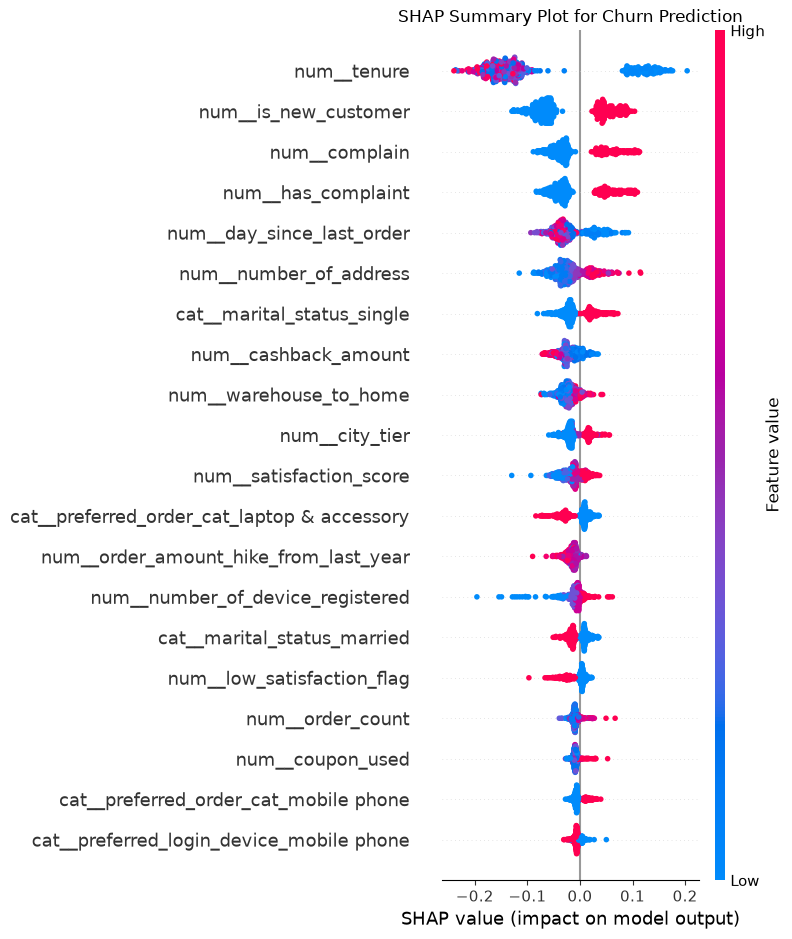

In [13]:
# Create and save SHAP summary plot

os.makedirs("../../05_outputs/figures", exist_ok=True)

plt.figure()

shap.summary_plot(
    shap_values_churn,
    X_shap_sample,
    show=False
)

plt.title("SHAP Summary Plot for Churn Prediction")
plt.tight_layout()

plt.savefig(
    "../../05_outputs/figures/shap_summary_plot.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [14]:
shap_importance = pd.DataFrame({
    "feature": X_shap_sample.columns,
    "mean_abs_shap_value": np.abs(shap_values_churn).mean(axis=0)
}).sort_values(
    "mean_abs_shap_value",
    ascending=False
)

shap_importance.head(20)

,feature,mean_abs_shap_value
0,num__tenure,0.142063
17,num__is_new_customer,0.065463
7,num__complain,0.046149
19,num__has_complaint,0.045847
11,num__day_since_last_order,0.035132
6,num__number_of_address,0.031080
39,cat__marital_status_single,0.025021
12,num__cashback_amount,0.023122
2,num__warehouse_to_home,0.022628
1,num__city_tier,0.020289


In [15]:
shap_importance["clean_feature"] = (
    shap_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

shap_importance.head(20)

,feature,mean_abs_shap_value,clean_feature
0,num__tenure,0.142063,tenure
17,num__is_new_customer,0.065463,is_new_customer
7,num__complain,0.046149,complain
19,num__has_complaint,0.045847,has_complaint
11,num__day_since_last_order,0.035132,day_since_last_order
6,num__number_of_address,0.031080,number_of_address
39,cat__marital_status_single,0.025021,marital_status_single
12,num__cashback_amount,0.023122,cashback_amount
2,num__warehouse_to_home,0.022628,warehouse_to_home
1,num__city_tier,0.020289,city_tier


In [16]:
os.makedirs("../../05_outputs/model_results", exist_ok=True)

shap_importance.to_csv(
    "../../05_outputs/model_results/shap_feature_importance.csv",
    index=False
)

os.path.exists("../../05_outputs/model_results/shap_feature_importance.csv")

True

## SHAP Explainability Summary and Conclusion

SHAP was used to explain the selected Random Forest churn prediction model.

The SHAP analysis shows that `tenure` is the most influential feature in the model. This means customer lifecycle stage plays a major role in churn prediction. Customers with shorter tenure are more likely to be identified as churn-risk customers.

The second most important feature is `is_new_customer`, which supports the finding that newly acquired customers are a key churn-risk group. This is consistent with the EDA and risk segmentation results.

Complaint-related features, including `complain` and `has_complaint`, are also among the top predictors. This indicates that customer complaints are strong signals of churn risk and should be prioritized in retention actions.

Other important features include `day_since_last_order`, `number_of_address`, `cashback_amount`, `warehouse_to_home`, `city_tier`, and `satisfaction_score`. These features suggest that churn prediction is influenced by a combination of customer lifecycle, service experience, engagement behavior, purchase behavior, and customer profile.

The SHAP results support the business recommendation that the company should prioritize:

- Low-tenure and new customers
- Customers with complaint history
- Customers with declining or limited engagement
- Customers in product and profile groups with higher churn signals

Compared with traditional feature importance, SHAP provides a more interpretable view of how different features contribute to churn prediction. This makes the model easier to explain to business stakeholders.

The SHAP feature importance table was saved to:

- `05_outputs/model_results/shap_feature_importance.csv`

The SHAP summary plot was saved to:

- `05_outputs/figures/shap_summary_plot.png`